# K-Means Clustring example
# K-Means comes under unsupervised machine learning technique
# Terms we will use here like **cluster & centroid**
# **Cluster:** we will partition our dataset into K distinct cluster
# **Centroid:** Nearest mean cluster

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

In [32]:
X = np.array([
    [7.5, 8.0],
    [9.0, 7.0],
    [10.5, 6.5],
    [6.0, 9.0],
    [13.0, 5.5],
    [8.0, 8.5],
    [14.0, 4.5],
    [9.5, 7.0],
    [7.0, 9.0],
    [12.0, 6.0]
])

df=pd.DataFrame(X, columns=['EntryTime','Duration'])
df

,EntryTime,Duration
0,7.5,8.0
1,9.0,7.0
2,10.5,6.5
3,6.0,9.0
4,13.0,5.5
5,8.0,8.5
6,14.0,4.5
7,9.5,7.0
8,7.0,9.0
9,12.0,6.0


In [33]:
# create model
model= KMeans(n_clusters=3, random_state=0)

In [34]:
df['Cluster']= model.fit_predict(df[['EntryTime','Duration']])
centers= model.cluster_centers_
df

,EntryTime,Duration,Cluster
0,7.5,8.0,0
1,9.0,7.0,2
2,10.5,6.5,2
3,6.0,9.0,0
4,13.0,5.5,1
5,8.0,8.5,0
6,14.0,4.5,1
7,9.5,7.0,2
8,7.0,9.0,0
9,12.0,6.0,1


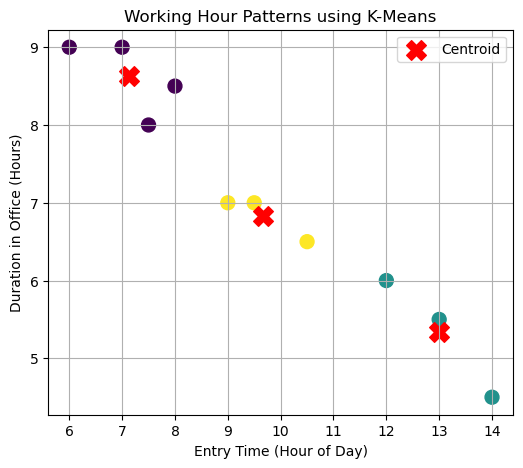

In [35]:
plt.figure(figsize=(6,5))
plt.scatter(df['EntryTime'], df['Duration'], c=df['Cluster'], cmap='viridis', s=100)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200, c='red', label='Centroid')
plt.xlabel('Entry Time (Hour of Day)')
plt.ylabel('Duration in Office (Hours)')
plt.title('Working Hour Patterns using K-Means')
plt.legend()
plt.grid(True)
plt.show()

# Lab: Customer segmentation using k-means
**Goal**: Group customers by Annual Income and Spending Score.

1. load data from customer.csv from github.com
2. Visualize the data
3. cluster
4. Interpret each segment like 'High Income / high spender' etc.
5. create scatter plot for the same 

In [36]:
df = pd.read_csv('customers.csv')
df.head()

,CustomerID,AnnualIncome,SpendingScore
0,1,15,79
1,2,16,81
2,3,17,76
3,4,18,75
4,5,19,73


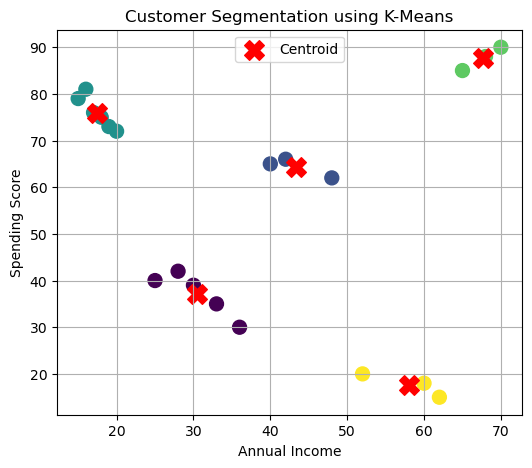

In [43]:
df = pd.read_csv('customers.csv')
X = df[['AnnualIncome','SpendingScore']]

n_clusters = 4
kmeans = KMeans(n_clusters=5, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

labels = {0:'HI/HS', 1:'HI/LS', 2:'LI/HS', 3:'LI/LS'}  # untuk ni... n_clusters = 4
df['Segment'] = df['Cluster'].map(labels)

plt.figure(figsize=(6,5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis', s=100)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200, c='red', label='Centroid')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.legend(loc='upper center')
plt.grid(True)
os.environ["OMP_NUM_THREADS"] = "1"
plt.show()